In [7]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Suppress TensorFlow logging warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Create results directory for outputs
os.makedirs('results', exist_ok=True)
print("Libraries imported and 'results' folder created successfully!")

Libraries imported and 'results' folder created successfully!


--- Task 1: Dataset Understanding ---
Total Records: 1500

Dataset Columns and Types:
 ticket_id             str
channel               str
customer_message      str
sentiment_label       str
word_count          int64
urgent_flag         int64
dtype: object

Sample Text Records:
                                     customer_message sentiment_label
0  I need information about the payment process. ...         neutral
1      I need information about the payment process.         neutral
2  The refund process was fast and convenient. I ...        positive
3  My refund is still pending and this experience...        negative
4   Please tell me how to update my account details.         neutral

Average Text Length: 72.76 characters

Class Distribution:
 sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


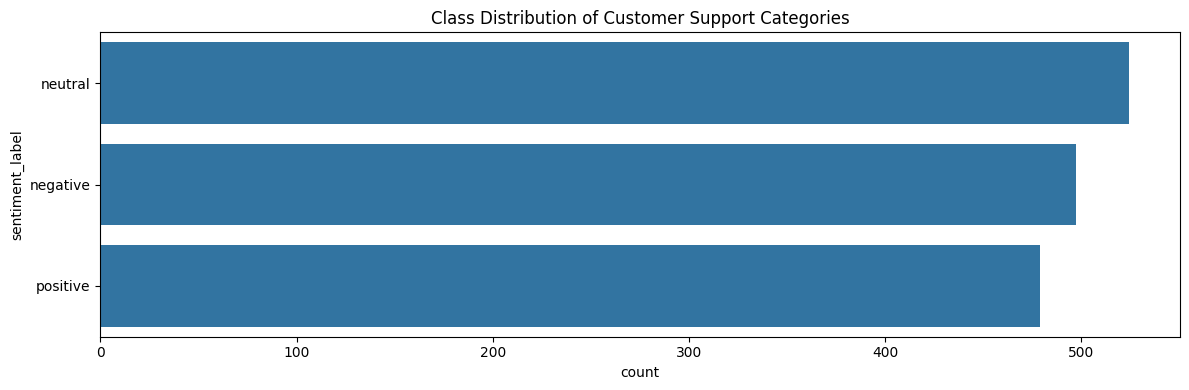

In [13]:
## Task 1: Dataset Understanding & Exploration
print("--- Task 1: Dataset Understanding ---")
# File path for Customer Support Text Classification
file_path = r'C:\Users\Lenovo\Downloads\ai_project_synthetic_datasets-20260514T180014Z-3-001\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv'
df = pd.read_csv(file_path)

print(f"Total Records: {df.shape[0]}")
print("\nDataset Columns and Types:\n", df.dtypes)

# Dataset columns configuration
text_col = 'text'   
label_col = 'category' 

text_col = 'customer_message'
label_col = 'sentiment_label'

print("\nSample Text Records:\n", df[[text_col, label_col]].head())

# Text length statistics
df['text_length'] = df[text_col].astype(str).apply(len)
print(f"\nAverage Text Length: {df['text_length'].mean():.2f} characters")
print("\nClass Distribution:\n", df[label_col].value_counts())

# Save class distribution plot
plt.figure(figsize=(12, 4))
sns.countplot(data=df, y=label_col, order=df[label_col].value_counts().index)
plt.title('Class Distribution of Customer Support Categories')
plt.tight_layout()
plt.savefig('results/class_distribution.png')
plt.show()

In [9]:
## Task 2: Text Preprocessing & Cleaning

print("--- Task 2: Text Preprocessing ---")

def clean_text(text):
    text = str(text).lower()  # Lowercasing
    text = re.sub(r'[^a-z\s]', '', text)  # Removing special characters
    return text

df['cleaned_text'] = df[text_col].apply(clean_text)
print("Sample cleaned text:\n", df['cleaned_text'].head())

# Convert category strings into numerical labels automatically
df['target'] = df[label_col].astype('category').cat.codes
num_classes = df['target'].nunique()

# Split dataset (80% Train, 20% Test) with Stratification
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    df['cleaned_text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)
print(f"\nTotal unique categories: {num_classes}")
print(f"Training records: {len(X_train_txt)} | Testing records: {len(X_test_txt)}")

--- Task 2: Text Preprocessing ---
Sample cleaned text:
 0    i need information about the payment process m...
1         i need information about the payment process
2    the refund process was fast and convenient i a...
3    my refund is still pending and this experience...
4      please tell me how to update my account details
Name: cleaned_text, dtype: str

Total unique categories: 3
Training records: 1200 | Testing records: 300


In [10]:
## Task 3 & 4: Text Vectorization & Baseline Model (Naive Bayes)

print("--- Tasks 3 & 4: Baseline Model (TF-IDF + Naive Bayes) ---")

# Text Vectorization using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf = tfidf.transform(X_test_txt)

# Build and Evaluate Baseline Naive Bayes Model
baseline_model = MultinomialNB()
baseline_model.fit(X_train_tfidf, y_train)
y_pred_baseline = baseline_model.predict(X_test_tfidf)

print(f"Baseline Model Train Accuracy: {accuracy_score(y_train, baseline_model.predict(X_train_tfidf)):.4f}")
print(f"Baseline Model Test Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print("\nClassification Report (Baseline):\n", classification_report(y_test, y_pred_baseline))

--- Tasks 3 & 4: Baseline Model (TF-IDF + Naive Bayes) ---
Baseline Model Train Accuracy: 1.0000
Baseline Model Test Accuracy: 1.0000

Classification Report (Baseline):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        99
           1       1.00      1.00      1.00       105
           2       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [11]:
## Task 5: Sequence Model Architecture (LSTM Configuration)
print("--- Task 5: Building Sequence Model Architecture ---")

max_words = 10000
max_len = 150  

# Tokenization and Text Padding for deep learning sequences
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train_txt)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_txt), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_txt), maxlen=max_len)

# Keras Sequential Model setup with explicit Input layer
lstm_model = Sequential([
    Input(shape=(max_len,)),                          
    Embedding(input_dim=max_words, output_dim=64),    
    LSTM(64, dropout=0.2),                           
    Dense(num_classes, activation='softmax')                     
])

# Multi-class loss function compilation
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',                      
    metrics=['accuracy']                              
)

lstm_model.summary()

--- Task 5: Building Sequence Model Architecture ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,219 (2.57 MB)

 Trainable params: 673,219 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

--- Training and Evaluating Sequence Model ---
Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 1.0000 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 0.0015
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

LSTM Final Train Accuracy: 1.0000
LSTM Final Test Accuracy: 1.0000


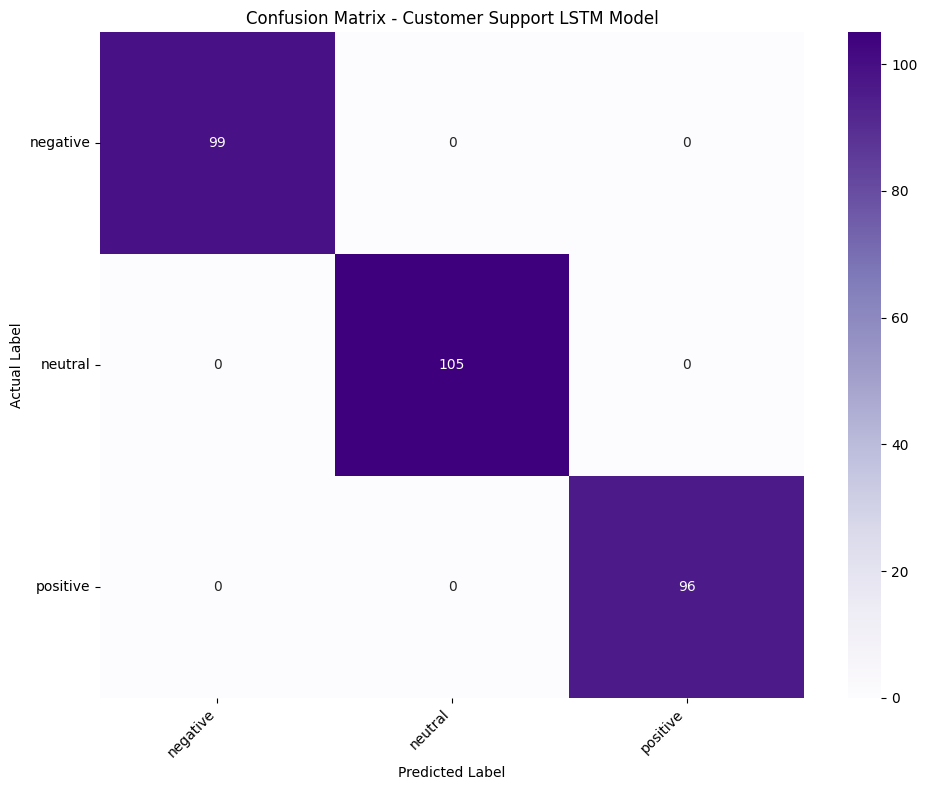


All steps for Task 5 completed successfully! Outputs saved inside 'results/'.


In [16]:
## Sequence Model Training and Evaluation

print("--- Training and Evaluating Sequence Model ---")

# Train the LSTM Network
history = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=5,
    batch_size=64,
    verbose=1
)

# Predict categories using argmax for highest probability class
y_pred_lstm_prob = lstm_model.predict(X_test_seq)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1) 

print(f"\nLSTM Final Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"LSTM Final Test Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")

# Map codes back to real department names for visual tracking
category_names = df[label_col].astype('category').cat.categories.tolist()

# Generate Confusion Matrix Heatmap Plot
cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=category_names, yticklabels=category_names)
plt.title('Confusion Matrix - Customer Support LSTM Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('results/model_evaluation.png')
plt.show()

# Log sample predictions to a txt file
with open('results/sample_predictions.txt', 'w') as f:
    f.write("Sample Text -> Actual Category -> Predicted Category\n")
    for i in range(min(5, len(X_test_txt))):
        pred_cat = category_names[y_pred_lstm[i]]
        actual_cat = category_names[y_test.iloc[i]]
        
        # Slicing [:50] hata kar sirf X_test_txt.iloc[i] rakha hai poore text ke liye
        f.write(f"Text: {X_test_txt.iloc[i]} | Actual: {actual_cat} | Pred: {pred_cat}\n")

print("\nAll steps for Task 5 completed successfully! Outputs saved inside 'results/'.")